<a href="https://colab.research.google.com/github/Dhanshree010/Machine-Vision-Practical/blob/main/practical5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload a face image (e.g., student.jpg)


Saving db photo.jpg to db photo (1).jpg


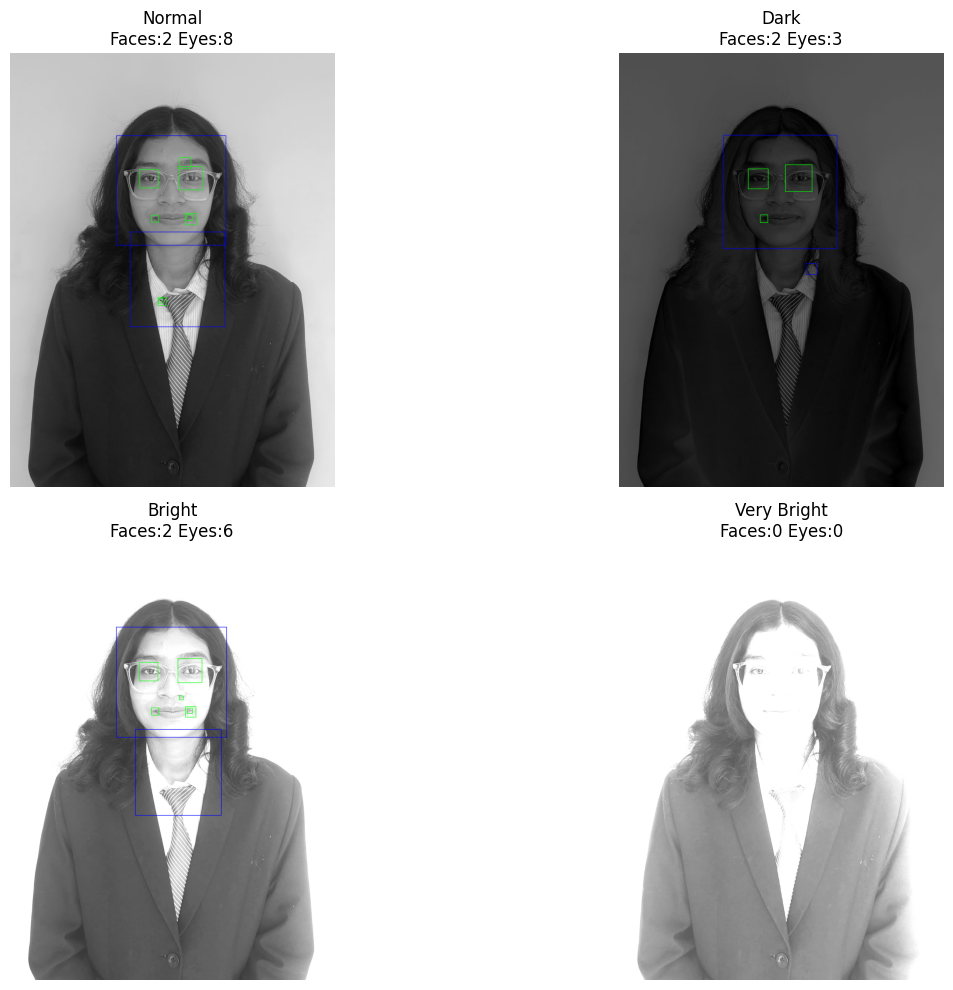

In [2]:
# ============================================
# Face and Eye Detection using Haar Cascade
# Attendance Automation Practical
# ============================================

# Install OpenCV (Run this only in Google Colab)
!pip install -q opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

# -----------------------------
# Upload Image
# -----------------------------
print("Upload a face image (e.g., student.jpg)")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# -----------------------------
# Load Image
# -----------------------------
image = cv2.imread(filename)

if image is None:
    print("Error: Image not found.")
    exit()

# -----------------------------
# Load Haar Cascade Classifiers
# -----------------------------
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

# -----------------------------
# Create Different Lighting Conditions
# -----------------------------
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

lighting_images = {
    "Normal": gray,
    "Dark": cv2.convertScaleAbs(gray, alpha=0.6, beta=-40),
    "Bright": cv2.convertScaleAbs(gray, alpha=1.4, beta=40),
    "Very Bright": cv2.convertScaleAbs(gray, alpha=2.0, beta=70)
}

results = []

plt.figure(figsize=(15,10))

for i, (condition, img) in enumerate(lighting_images.items(), 1):

    output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    faces = face_cascade.detectMultiScale(
        img,
        scaleFactor=1.2,
        minNeighbors=5,
        minSize=(30,30)
    )

    face_count = len(faces)
    eye_count = 0

    for (x, y, w, h) in faces:

        cv2.rectangle(output, (x, y), (x+w, y+h), (255,0,0), 2)

        roi_gray = img[y:y+h, x:x+w]
        roi_color = output[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.1,
            minNeighbors=4
        )

        eye_count += len(eyes)

        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(
                roi_color,
                (ex, ey),
                (ex+ew, ey+eh),
                (0,255,0),
                2
            )

    accuracy = min((face_count/1)*100, 100)

    results.append([
        condition,
        face_count,
        eye_count,
        accuracy
    ])

    plt.subplot(2,2,i)
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title(f"{condition}\nFaces:{face_count} Eyes:{eye_count}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# Result Table
# -----------------------------



Detection Results

  Lighting Condition  Detected Faces  Detected Eyes  Detection Accuracy (%)
0             Normal               2              8                   100.0
1               Dark               2              3                   100.0
2             Bright               2              6                   100.0
3        Very Bright               0              0                     0.0


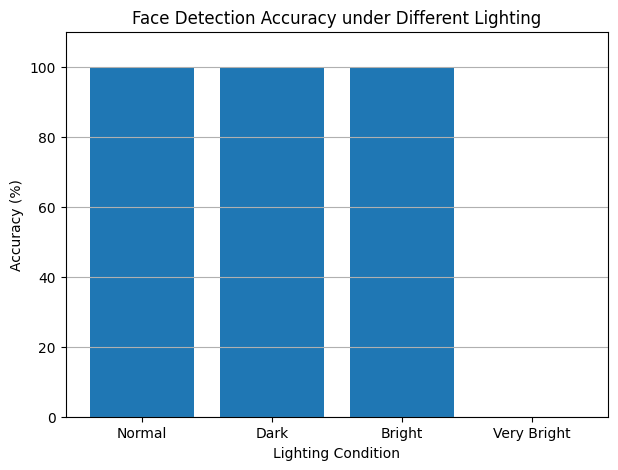

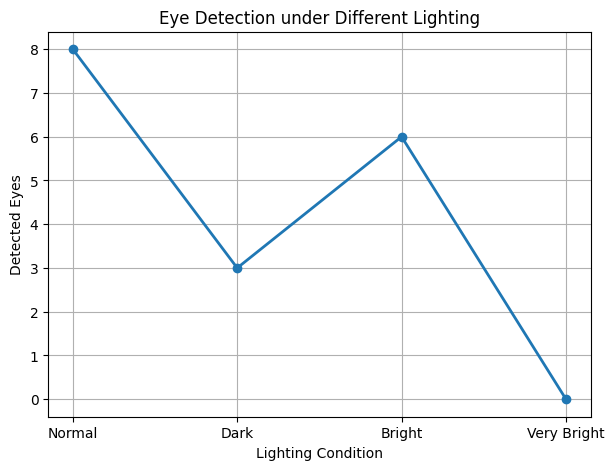

In [3]:
df = pd.DataFrame(
    results,
    columns=[
        "Lighting Condition",
        "Detected Faces",
        "Detected Eyes",
        "Detection Accuracy (%)"
    ]
)

print("\nDetection Results\n")
print(df)

# -----------------------------
# Accuracy Graph
# -----------------------------
plt.figure(figsize=(7,5))
plt.bar(df["Lighting Condition"], df["Detection Accuracy (%)"])
plt.title("Face Detection Accuracy under Different Lighting")
plt.xlabel("Lighting Condition")
plt.ylabel("Accuracy (%)")
plt.ylim(0,110)
plt.grid(axis='y')
plt.show()

# -----------------------------
# Eye Detection Graph
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(
    df["Lighting Condition"],
    df["Detected Eyes"],
    marker='o',
    linewidth=2
)
plt.title("Eye Detection under Different Lighting")
plt.xlabel("Lighting Condition")
plt.ylabel("Detected Eyes")
plt.grid(True)
plt.show()
